<a href="https://colab.research.google.com/github/nicolastibata/MINE_4206_AML_202610/blob/main/labs/lab_5/MINE_4206_AML_202610_L5_S2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo AML](https://github.com/nicolastibata/MINE_4206_AML_202610/blob/main/docs/logo.jpg?raw=true)

# **Laboratorio 5 - Sesión 2: Isolation Forest + Autoencoders**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=R4YrUaE6udsU&line=14&uniqifier=1)<br>
[1. Introducción de los datos](#scrollTo=VjA8zwzJvmeO&line=1&uniqifier=1)<br>
[2. Preparación y Modelamiento](#scrollTo=kG8XHROzvuEH&line=1&uniqifier=1)<br>
[3. Preguntas](#scrollTo=HnWtjBcSv3yG&line=1&uniqifier=1)<br>


### **Contexto y Objetivos**

**Problema**

Los accidentes cerebrovasculares (ACV), conocidos comúnmente como derrame cerebral, generan afectaciones o bloqueos en el flujo sanguíneo en el cerebro. Existen estudios que han relacionado distintas causas con los ACV, como el índice de masa corporal (BMI en inglés), la edad, entre otros. Con miras a realizar un proceso de detección temprana para esta enfermedad, se construirá un modelo  a partir de los datos relacionados con  pacientes sanos. Posteriormente, se evaluará la capacidad del modelo en la identificación de pacientes que hayan sufrido un derrame cerebral.

Para lograr este propósito construiremos un modelo que permita aprender de los pacientes sanos y sin presentar un derrame cerebral y posteriormente reconstruiremos combinando pacientes sin derrames (sanos) junto con pacientes que hayan sufrido un derrame.

**Objetivos**

1. Resolver un problema de detección de anomalías.
2. Realizar el entrenamiento de una sola clase.
3. Analizar la Arquitectura de los AutoEncoders e IsolationForest.

Los datos los puedes encontrar acá: [Cerebral Stroke Prediction](https://www.kaggle.com/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset)

**Diccionario**

| ATRIBUTO | DEFINICIÓN |
| :- | :- |
| **id** | Corresponde al identificador.|
| **gender** | Género del paciente.|
| **age** | Edad del paciente.|
| **hypertension** | Indica si el paciente sufre o no de hipertensión.|
| **heart_disease** | Indica si el paciente sufre de enfermedades del corazón.|
| **ever_married** | Registra si el usuario siempre ha estado casado.|
| **work_type** | Relaciona el tipo de trabajo del paciente.|
| **residence_type** | Indica el tipo de recidencia del paciente.|
| **avg_glucose_level** | Registra el nivel de glucosa.|
| **bmi** | Índice de masa corporal del paciente.|
| **smoking_status** | Información acerca de si el paciente fuma y la frecuencia.|
| **stroke** | Información acerca de ataques cerebrales.|


### **1. Introducción a los datos**

In [1]:
!pip install ydata-profiling -q
# Acceso a credenciales
import os
from google.colab import files
from google.colab import userdata


import pandas as pd
import numpy as np
import sys
import os
import os.path as osp
import joblib
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

#Tensorflow y keras
import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.utils import plot_model
from keras.optimizers import Adam

import sklearn
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler, Normalizer, StandardScaler
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import IsolationForest


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.8 MB/s eta 0:00:00


/tmp/ipykernel_5182/1123477075.py:14: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d shashwatwork/cerebral-stroke-predictionimbalaced-dataset
! unzip "cerebral-stroke-predictionimbalaced-dataset.zip"

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset
License(s): Attribution-NonCommercial-ShareAlike 3.0 IGO (CC BY-NC-SA 3.0 IGO)
100% 560k/560k [00:00<00:00, 25.3MB/s]

Archive:  cerebral-stroke-predictionimbalaced-dataset.zip
  inflating: dataset.csv             


In [3]:
df = pd.read_csv("/content/dataset.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0


In [4]:
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:04<00:00,  2.55it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Los datos tienen un total de 12 variables o características, un total de 47.430 instancias. No tiene instancias (filas) duplicadas.

Los tipos de datos para las variables se distribuyen de la siguiente forma:
* 4 numéricas.
* 7 categóricas.
* 1 booleana (verdadero y falso).

|ATRIBUTO | ACCIONES |
|---| :- |
| **id** | Se recomienda eliminar esta característica.|
| **gender** | Cuenta con 3 categorías, 2 de ellas balanceadas y algunos valores para la categoría `Others`. No presenta ausencias.|
| **age** | Presenta un comportamiento similar a una distribución normal. No presenta ausencias.|
| **hypertension** | La clase no está balanceada, no obstante en el contexto de la organización el porcentaje de hipertensión no suele ser alto.|
| **heart_disease** | La clase no está balanceada, no obstante en el contexto de la organización el porcentaje de heart disease no suele ser alto.|
| **ever_married** | Como es variable booleana, se debe realizar la transformación. No presenta ausencias.|
| **work_type** | Cuenta con 5 categorías. No presenta ausencias.|
| **residence_type** | La clase está balanceada. No presenta ausencias.|
| **avg_glucose_level** | Registra el nivel de glucosa.|
| **bmi** | Índice de masa corporal del paciente. 1.085 el cuál supera el 3% de los datos, presenta ausencias, se recomienda eliminar estos valores.|
| **smoking_status** | Presenta 3 categorías `never smoked`, `formerly smoked` y `smokes`. Pero cuenta con 10.503 ausencias, en este contexto de salud es mejor eliminar la variable debido a informacion sensible.|

### **2. Preparación y Modelamiento**

#### **Preparación de nuestro pipeline**

In [5]:
def fix_num_values(df):
  for column in df.columns:
    #Conversión de valores booleanos a números
    if np.isin(column, bool_to_num_fields) == True:
      df[column] = df[column].astype(bool)
      df[column] = df[column].map({True: 1, False: 0})

  return df


def fix_cat_values(df):
  for column in df.columns:
    df[column] = df[column].fillna('No Information')

  return df


num_transformer = Pipeline(
    steps=[
        ('transform', FunctionTransformer(fix_num_values, validate=False)),
        ('scaler', StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ('transform', FunctionTransformer(fix_cat_values, validate=False)),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

bool_transformer = Pipeline(
    steps=[
        ('transform', FunctionTransformer(fix_num_values, validate=False))
    ]
)

In [69]:
target_feature = "stroke"

all_num_fields = df.select_dtypes(include=[np.number]).columns.tolist()
num_fields = [col for col in all_num_fields if col not in drop_fields and col != target_feature]

cat_fields = ["gender", "Residence_type"]

#Características a eliminar
drop_fields = ["id", "smoking_status"]
#Columnas con ausencias por eliminar
missing_val_fields = ["bmi"]
#Columnas con valores verdadero o falso que requieren transformación a número
bool_to_num_fields = ["ever_married"]

print(target_feature)
print(num_fields)
print(cat_fields)
print(drop_fields)
print(missing_val_fields)
print(bool_to_num_fields)

stroke
['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
['gender', 'Residence_type']
['id', 'smoking_status']
['bmi']
['ever_married']


In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, num_fields),
        ("bool", bool_transformer, bool_to_num_fields),
        ("cat", cat_transformer, cat_fields)
    ]
)

pipe = Pipeline(steps=[
    ('column_transformer', preprocessor)
])

pipe

Pipeline(steps=[('column_transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('transform',
                                                                   FunctionTransformer(func=<function fix_num_values at 0x7e71ccdc3880>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('bool',
                                                  Pipeline(steps=[('transform',
                                                                   FunctionTransformer(func=<function fix_num_values at 0x7e71ccdc3880>))]),
                                                  ['ever_married']),
                                                 ('cat',
                                                  Pipeline(steps=[('transform',
                                                                   FunctionTransformer(func=<function fix_cat_values at 0x7e71ccdc37e0>)),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'Residence_type'])]))])

In [71]:
# Dejamos funciones complementarias antes del pipe

#Función de borrado de features no usados
def drop_features(train_, test_, features):
  train_ = train_.drop(features, axis=1)
  test_ = test_.drop(features, axis=1)

  return train_, test_

#Función de borrado de instancias (registros) con ausencias
def drop_missing_values(train_, test_, features):
  for feature in features:
    train_ = train_[train_[feature].isnull() == False]
    test_ = test_[test_[feature].isnull() == False]

  return train_, test_

#### **Modelamiento**

##### **Modelo Isolation Forest**

Para detectar anomalías con Isolation Forest necesitamos hacer split de los datos incluyendo una parte de los datos anómalos

In [118]:
train, test = train_test_split(df, test_size=0.2, random_state=19, stratify=df['stroke'])
print(train.shape)
print(test.shape)

(34720, 12)
(8680, 12)


In [119]:
train_t, test_t = drop_features(train, test, drop_fields)
train_t, test_t = drop_missing_values(train_t, test_t, missing_val_fields)
print(train_t.shape)
print(test_t.shape)

(33521, 10)
(8417, 10)


In [120]:
X_train, y_train = train_t.drop([target_feature], axis=1), train_t[target_feature]
display(X_train)
display(y_train)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi
26047,Female,55.0,0,0,Yes,Self-employed,Rural,62.18,22.9
10512,Male,56.0,0,0,Yes,Self-employed,Rural,69.03,28.7
42640,Female,12.0,0,0,No,children,Urban,90.05,22.9
32323,Female,82.0,1,1,Yes,Self-employed,Rural,105.08,20.9
22743,Female,44.0,0,0,Yes,Private,Rural,187.40,23.1
...,...,...,...,...,...,...,...,...,...
17271,Female,26.0,0,0,No,Govt_job,Rural,102.40,32.0
3259,Female,54.0,0,0,Yes,Self-employed,Urban,56.75,26.9
21843,Male,71.0,0,0,Yes,Self-employed,Urban,60.86,30.3
12190,Male,29.0,0,0,No,Private,Urban,57.19,26.2


,stroke
26047,0
10512,0
42640,0
32323,0
22743,0
...,...
17271,0
3259,0
21843,0
12190,0


In [121]:
num_column_names = np.hstack((pipe['column_transformer'].transformers_[0][1].feature_names_in_, pipe['column_transformer'].transformers_[1][1].feature_names_in_))
cat_column_names = pipe['column_transformer'].transformers_[2][1][1].get_feature_names_out()
col_names = list(num_column_names) + list(cat_column_names)

X_new_train = pd.DataFrame(pipe.fit_transform(X_train), columns=col_names)
X_new_train

,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married,gender_Female,gender_Male,gender_Other,Residence_type_Rural,Residence_type_Urban
0,0.586091,-0.308614,-0.211941,-0.982428,-0.733098,1.0,1.0,0.0,0.0,1.0,0.0
1,0.630610,-0.308614,-0.211941,-0.820582,0.012401,1.0,0.0,1.0,0.0,1.0,0.0
2,-1.328192,-0.308614,-0.211941,-0.323941,-0.733098,1.0,1.0,0.0,0.0,0.0,1.0
3,1.788083,3.240291,4.718296,0.031174,-0.990167,1.0,1.0,0.0,0.0,1.0,0.0
4,0.096391,-0.308614,-0.211941,1.976156,-0.707391,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
33516,-0.704937,-0.308614,-0.211941,-0.032146,0.436564,1.0,1.0,0.0,0.0,1.0,0.0
33517,0.541573,-0.308614,-0.211941,-1.110723,-0.218961,1.0,1.0,0.0,0.0,0.0,1.0
33518,1.298383,-0.308614,-0.211941,-1.013616,0.218056,1.0,0.0,1.0,0.0,0.0,1.0
33519,-0.571383,-0.308614,-0.211941,-1.100327,-0.308935,1.0,0.0,1.0,0.0,0.0,1.0


In [122]:
iso_forest = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=0.01, # Se ajusta basado en el ratio de stroke en los datos
    random_state=71,
    n_jobs=-1
)

iso_forest.fit(X_new_train)

IsolationForest(contamination=0.01, n_estimators=200, n_jobs=-1,
                random_state=71)

In [123]:
X_test, y_test = test_t.drop([target_feature], axis=1), test_t[target_feature]
display(X_test)
display(y_test)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi
12377,Male,65.00,0,0,Yes,Private,Urban,114.56,34.9
11330,Female,44.00,0,0,No,Govt_job,Rural,98.99,35.4
23197,Male,10.00,0,0,No,children,Urban,60.58,16.7
12111,Male,29.00,0,0,No,Private,Rural,74.58,24.1
6697,Male,48.00,0,0,Yes,Private,Rural,95.72,23.7
...,...,...,...,...,...,...,...,...,...
42063,Male,52.00,0,0,Yes,Private,Rural,186.29,30.8
15526,Female,0.64,0,0,No,children,Urban,83.57,21.8
26180,Male,9.00,0,0,No,children,Urban,88.93,20.9
32622,Male,13.00,0,0,No,Private,Rural,57.73,23.2


,stroke
12377,0
11330,0
23197,0
12111,0
6697,0
...,...
42063,0
15526,0
26180,0
32622,0


In [124]:
X_new_test = pd.DataFrame(pipe.transform(X_test), columns=col_names)
X_new_test

,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married,gender_Female,gender_Male,gender_Other,Residence_type_Rural,Residence_type_Urban
0,1.031274,-0.308614,-0.211941,0.255159,0.809314,1.0,0.0,1.0,0.0,0.0,1.0
1,0.096391,-0.308614,-0.211941,-0.112715,0.873581,1.0,1.0,0.0,0.0,1.0,0.0
2,-1.417229,-0.308614,-0.211941,-1.020231,-1.530011,1.0,0.0,1.0,0.0,0.0,1.0
3,-0.571383,-0.308614,-0.211941,-0.689452,-0.578857,1.0,0.0,1.0,0.0,1.0,0.0
4,0.274464,-0.308614,-0.211941,-0.189975,-0.630271,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
8412,0.452537,-0.308614,-0.211941,1.949930,0.282323,1.0,0.0,1.0,0.0,1.0,0.0
8413,-1.833919,-0.308614,-0.211941,-0.477044,-0.874486,1.0,1.0,0.0,0.0,0.0,1.0
8414,-1.461747,-0.308614,-0.211941,-0.350403,-0.990167,1.0,0.0,1.0,0.0,0.0,1.0
8415,-1.283674,-0.308614,-0.211941,-1.087568,-0.694538,1.0,0.0,1.0,0.0,1.0,0.0


In [125]:
y_pred = iso_forest.predict(X_new_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1])

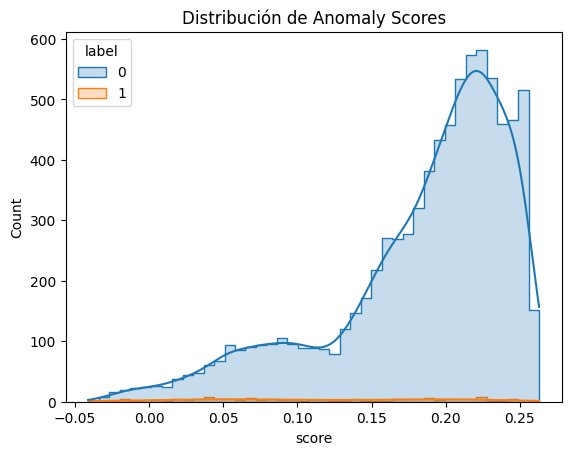

In [126]:
scores = iso_forest.decision_function(X_new_test)
results_df = pd.DataFrame({'score': scores, 'label': y_test})

sns.histplot(data=results_df, x='score', hue='label', element='step', kde=True)
plt.title("Distribución de Anomaly Scores")
plt.show()

Con `decision_functions` vemos los scores asignados a nuestras predicciones, idealmente esperamos que los valores negativos cercanos a -1 sean de nuestra clase 'stroke'.

In [127]:
y_pred_mapped = np.where(y_pred == -1, 1, 0)

print("Classification Report - Isolation Forest")
print(classification_report(y_test, y_pred_mapped))

Classification Report - Isolation Forest
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      8280
           1       0.10      0.07      0.08       137

    accuracy                           0.97      8417
   macro avg       0.54      0.53      0.53      8417
weighted avg       0.97      0.97      0.97      8417



##### **Modelo AutoEncoder**

Para el desarrollo del laboratorio se utilizará una arquitectura de Autoencoder estructurada de la siguiente manera:

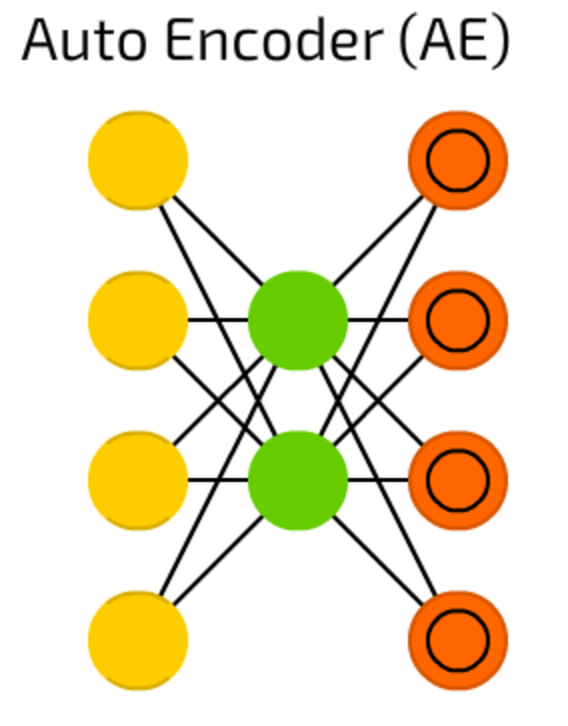

Los codificadores automáticos o autoencoders se utilizan para el preentrenamiento de otras redes, reducción de la dimensionalidad, aprendizaje de espacios latentes, entre otros.

Los autoencoders, por otro lado, pueden ser entrenados sin supervisión. Su estructura generalmente se caracteriza por:
1. La cantidad de neuronas ocultas es menor que la cantidad de celdas de entrada.
2. La cantidad de celdas de salida es igual a la cantidad de celdas de entrada.
3. El autoencoder se entrena de manera en que la salida está lo más cerca posible de la entrada, obligando a los autoencoders a generalizar datos y realizar búsqueda de patrones comunes.

>Además, en este caso lo que vamos a hacer es **reconstruir** los datos, por lo tanto no necesitamos incluir datos anómalos en nuestro dataset de entrenamiento.

In [130]:
normal_df = df[df["stroke"] == 0]
disease_df = df[df["stroke"] == 1]

train, test = train_test_split(normal_df, test_size=0.2, random_state=19)

#Vamos a realizar las pruebas combinando los datos de prueba de la clase normal y a su vez los pacientes con enfermedad
test = pd.concat([test, disease_df])
print(train.shape)
print(test.shape)

(34093, 12)
(9307, 12)


In [131]:
train_t, test_t = drop_features(train, test, drop_fields)
train_t, test_t = drop_missing_values(train_t, test_t, missing_val_fields)
print(train_t.shape)
print(test_t.shape)

(33008, 10)
(8930, 10)


In [132]:
X_train, y_train = train_t.drop([target_feature], axis=1), train_t[target_feature]
display(X_train)
display(y_train)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi
37105,Female,39.0,0,0,Yes,Private,Urban,152.99,27.6
25344,Male,64.0,0,0,Yes,Self-employed,Urban,72.26,23.2
11084,Male,13.0,0,0,No,Private,Rural,72.30,21.0
33531,Female,68.0,0,0,Yes,Govt_job,Urban,143.18,27.6
15315,Male,23.0,0,0,No,Private,Rural,122.69,31.0
...,...,...,...,...,...,...,...,...,...
34422,Female,79.0,0,0,Yes,Private,Rural,125.27,32.9
21795,Female,77.0,1,0,Yes,Govt_job,Urban,192.87,30.7
34764,Female,12.0,0,0,No,children,Urban,79.06,26.7
17429,Male,53.0,0,0,Yes,Self-employed,Urban,86.54,31.8


,stroke
37105,0
25344,0
11084,0
33531,0
15315,0
...,...
34422,0
21795,0
34764,0
17429,0


In [133]:
num_column_names = np.hstack((pipe['column_transformer'].transformers_[0][1].feature_names_in_, pipe['column_transformer'].transformers_[1][1].feature_names_in_))
cat_column_names = pipe['column_transformer'].transformers_[2][1][1].get_feature_names_out()
col_names = list(num_column_names) + list(cat_column_names)

X_new_train = pd.DataFrame(pipe.fit_transform(X_train), columns=col_names)
X_new_train

,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married,gender_Female,gender_Male,gender_Other,Residence_type_Rural,Residence_type_Urban
0,-0.108915,-0.305875,-0.205383,1.202843,-0.128032,1.0,1.0,0.0,0.0,0.0,1.0
1,1.008520,-0.305875,-0.205383,-0.737723,-0.691189,1.0,0.0,1.0,0.0,0.0,1.0
2,-1.271047,-0.305875,-0.205383,-0.736761,-0.972768,1.0,0.0,1.0,0.0,1.0,0.0
3,1.187309,-0.305875,-0.205383,0.967032,-0.128032,1.0,1.0,0.0,0.0,0.0,1.0
4,-0.824073,-0.305875,-0.205383,0.474500,0.307136,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
33003,1.678980,-0.305875,-0.205383,0.536517,0.550318,1.0,1.0,0.0,0.0,1.0,0.0
33004,1.589586,3.269310,-0.205383,2.161467,0.268739,1.0,1.0,0.0,0.0,0.0,1.0
33005,-1.315744,-0.305875,-0.205383,-0.574266,-0.243223,1.0,1.0,0.0,0.0,0.0,1.0
33006,0.516848,-0.305875,-0.205383,-0.394464,0.409528,1.0,0.0,1.0,0.0,0.0,1.0


In [134]:
EPOCHS = 50
BATCH_SIZE = 32
METRICS = ["acc"]
INPUT_DIM = X_new_train.shape[1]
print(INPUT_DIM)

11


In [135]:
autoencoder = Sequential(name="Autoencoder")

#Encoder
autoencoder.add(Input(shape=(INPUT_DIM,))) #Capa de Entrada
autoencoder.add(Dense(16, activation='relu'))
autoencoder.add(Dense(8, activation='relu'))

autoencoder.add(Dense(4, activation='relu')) # Espacio latente

#Decoder
autoencoder.add(Dense(8, activation='relu'))
autoencoder.add(Dense(16, activation='relu'))
autoencoder.add(Dense(INPUT_DIM, activation='linear'))

In [136]:
autoencoder.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.0005), metrics=METRICS)
autoencoder.summary()

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 735 (2.87 KB)

 Trainable params: 735 (2.87 KB)

 Non-trainable params: 0 (0.00 B)

In [137]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)

Para detección de anomalías, nuestro input será nuestro conjunto X, y nuestra salida será el mismo conjunto X

In [138]:
history = autoencoder.fit(X_new_train, X_new_train,
  epochs=EPOCHS,
  shuffle=True,
  batch_size=BATCH_SIZE,
  callbacks=[early_stopping],
  validation_data=(X_new_train, X_new_train)
)

Epoch 1/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.6617 - loss: 0.3618 - val_acc: 0.8645 - val_loss: 0.1827
Epoch 2/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - acc: 0.7904 - loss: 0.1377 - val_acc: 0.6791 - val_loss: 0.1071
Epoch 3/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.6898 - loss: 0.0878 - val_acc: 0.6733 - val_loss: 0.0695
Epoch 4/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.6874 - loss: 0.0628 - val_acc: 0.6823 - val_loss: 0.0583
Epoch 5/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.6885 - loss: 0.0568 - val_acc: 0.6820 - val_loss: 0.0552
Epoch 6/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - acc: 0.6892 - loss: 0.0545 - val_acc: 0.6823 - val_loss: 0.0535
Epoch 7/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.6887 - loss: 0.0529 - val_acc: 0.6803 - val_loss: 0.0520
Epoch 8/50
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - acc: 0.6847 - loss: 0.0516 - val_acc: 0.6940 - val_loss: 0.0510
Epoch 9/50
1032/1032 ━━━━━━━━━━━━━━━━━━

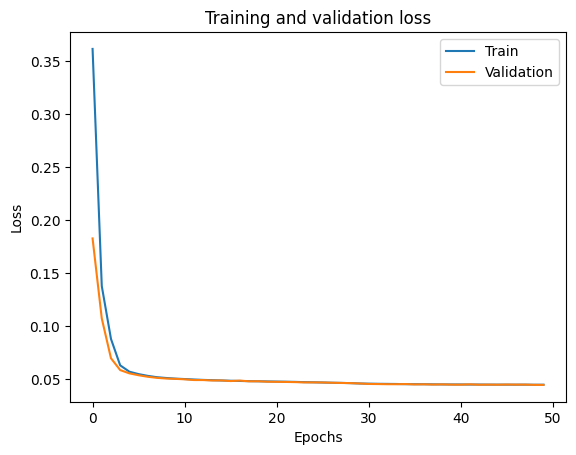

In [139]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

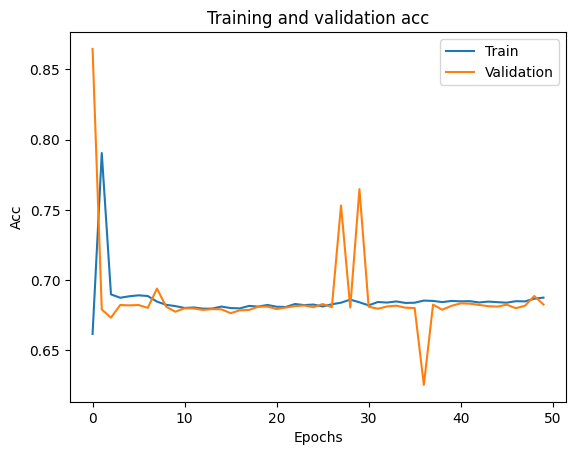

In [140]:
plt.plot(history.history['acc'], label='Train')
plt.plot(history.history['val_acc'], label='Validation')
plt.title('Training and validation acc')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()
plt.show()

In [141]:
predicted = autoencoder.predict(X_new_train)
pd.DataFrame(predicted)

1032/1032 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


,0,1,2,3,4,5,6,7,8,9,10
0,-0.037754,-0.311938,-0.202401,1.166913,-0.144220,1.003991,0.547898,0.437036,-0.001901,0.024002,0.976534
1,0.884426,-0.313630,-0.204790,-0.680733,-0.674338,1.001073,0.709446,0.281900,-0.000172,-0.037980,1.037286
2,-1.379083,-0.296862,-0.206091,-0.689924,-0.957938,1.001674,0.569105,0.420283,-0.000478,0.969351,0.033844
3,1.241650,-0.309593,-0.201801,0.940686,-0.142011,1.003660,0.668930,0.317794,-0.001721,0.018418,0.981009
4,-0.925689,-0.302253,-0.204205,0.520218,0.318967,1.002918,0.540724,0.443979,-0.001486,0.971909,0.031016
...,...,...,...,...,...,...,...,...,...,...,...
33003,1.716882,-0.296321,-0.202208,0.519515,0.538458,1.002944,0.771221,0.215642,-0.001560,1.014956,-0.014137
33004,1.630367,3.351780,-0.228618,2.149706,0.227676,1.012355,0.566141,0.399967,-0.008852,0.070049,0.933729
33005,-1.241971,-0.321658,-0.206564,-0.613835,-0.256437,1.000767,0.517972,0.470479,-0.000117,0.024156,0.976964
33006,0.404194,-0.323544,-0.205149,-0.342686,0.424447,1.000811,0.638113,0.350140,-0.000315,-0.034124,1.033746


Calculemos ahora el error en entrenamiento:

In [142]:
error = tf.keras.losses.MSE(X_new_train, predicted).numpy()
error

array([0.03665507, 0.09461879, 0.0614734 , ..., 0.04202262, 0.07706522,
       0.02041955], dtype=float32)

/tmp/ipykernel_5182/4268593782.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


<Axes: ylabel='Density'>

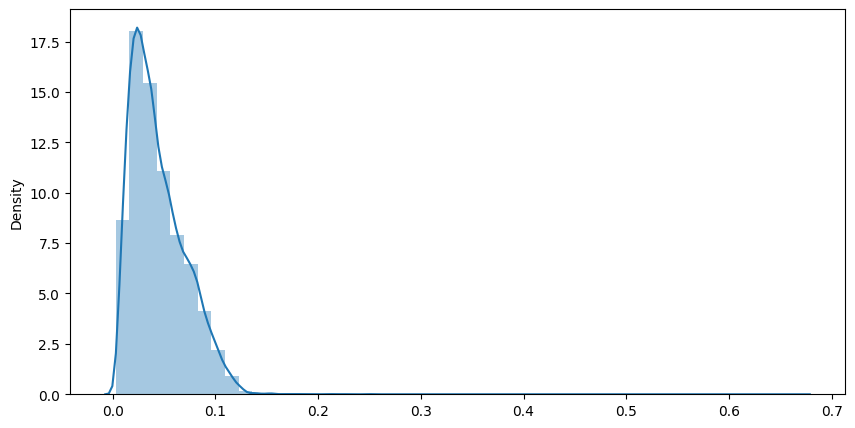

In [143]:
plt.rcParams['figure.figsize'] = [10, 5]
sns.distplot(error)

Nos dice que nuestro error de entrenamiento es amplio, una campana más estrecha nos dice que hay una mejor predicción ya que es más fácil identificar la anomalía

0.11865699


/tmp/ipykernel_5182/3076169620.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error)


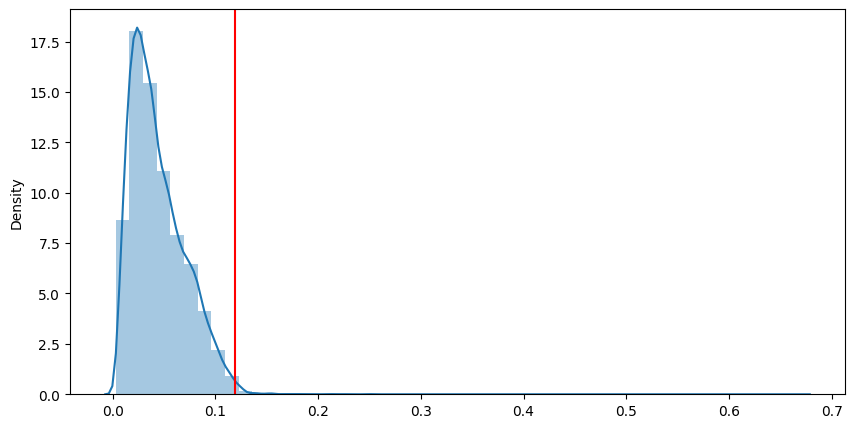

In [144]:
q = np.quantile(error, (0.994))
print(q)

sns.distplot(error)
plt.axvline(q, 0, 1, color = 'red')
plt.show()

**Realicemos las reconstrucciones**

In [145]:
X_test, y_test = test_t.drop([target_feature], axis=1), test_t[target_feature]
display(X_test)
display(y_test)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi
6974,Female,34.0,0,0,Yes,Private,Urban,56.98,32.2
36276,Female,14.0,0,0,No,children,Urban,63.95,24.9
28944,Male,11.0,0,0,No,children,Rural,78.83,20.5
12738,Female,14.0,0,0,No,Never_worked,Rural,94.69,22.6
2761,Female,34.0,0,0,Yes,Self-employed,Rural,78.12,32.0
...,...,...,...,...,...,...,...,...,...
43130,Female,82.0,0,1,Yes,Self-employed,Urban,118.61,29.4
43148,Female,56.0,0,0,Yes,Private,Rural,83.27,32.9
43268,Male,69.0,0,0,Yes,Self-employed,Rural,97.36,28.0
43304,Female,80.0,0,0,Yes,Self-employed,Urban,75.91,26.7


,stroke
6974,0
36276,0
28944,0
12738,0
2761,0
...,...
43130,1
43148,1
43268,1
43304,1


In [146]:
X_new_test = pd.DataFrame(pipe.transform(X_test), columns=col_names)
X_new_test

,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married,gender_Female,gender_Male,gender_Other,Residence_type_Rural,Residence_type_Urban
0,-0.332402,-0.305875,-0.205383,-1.105019,0.460724,1.0,1.0,0.0,0.0,0.0,1.0
1,-1.226350,-0.305875,-0.205383,-0.937476,-0.473606,1.0,1.0,0.0,0.0,0.0,1.0
2,-1.360442,-0.305875,-0.205383,-0.579795,-1.036764,1.0,0.0,1.0,0.0,1.0,0.0
3,-1.226350,-0.305875,-0.205383,-0.198557,-0.767984,1.0,1.0,0.0,0.0,1.0,0.0
4,-0.332402,-0.305875,-0.205383,-0.596862,0.435126,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
8925,1.813072,-0.305875,4.868941,0.376426,0.102351,1.0,1.0,0.0,0.0,0.0,1.0
8926,0.650941,-0.305875,-0.205383,-0.473068,0.550318,1.0,1.0,0.0,0.0,1.0,0.0
8927,1.232006,-0.305875,-0.205383,-0.134376,-0.076835,1.0,0.0,1.0,0.0,1.0,0.0
8928,1.723678,-0.305875,-0.205383,-0.649985,-0.243223,1.0,1.0,0.0,0.0,0.0,1.0


In [147]:
reconstructions = autoencoder.predict(X_new_test)
pd.DataFrame(reconstructions)

280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


,0,1,2,3,4,5,6,7,8,9,10
0,-0.271421,-0.327864,-0.207137,-1.136992,0.449771,0.999335,0.614436,0.375117,0.000479,0.019759,0.980333
1,-1.156662,-0.320872,-0.207035,-0.975291,-0.485704,1.000292,0.543586,0.446228,0.000201,0.022680,0.978316
2,-1.466621,-0.295830,-0.205840,-0.533930,-1.022409,1.002001,0.555915,0.433100,-0.000639,0.970019,0.033294
3,-1.162900,-0.294900,-0.205158,-0.232655,-0.781091,1.002411,0.569407,0.418734,-0.000928,1.023023,-0.019818
4,-0.278285,-0.305356,-0.205829,-0.624743,0.423628,1.000828,0.645950,0.342073,-0.000379,1.019804,-0.017596
...,...,...,...,...,...,...,...,...,...,...,...
8925,1.306859,-0.322280,4.743216,0.361662,0.042320,1.011260,0.438845,0.542871,-0.015806,-0.044502,1.063727
8926,0.694580,-0.303332,-0.204881,-0.494561,0.539690,1.001037,0.723881,0.264557,-0.000522,1.016431,-0.015012
8927,1.101014,-0.296015,-0.203477,-0.072528,-0.060754,1.002262,0.747523,0.241228,-0.001031,0.962081,0.039086
8928,1.745623,-0.288470,-0.190640,-0.668081,-0.242732,0.989005,0.793476,0.206721,0.004345,0.001971,1.001887


In [148]:
mse = np.mean(np.power(X_new_test - reconstructions, 2), axis=1)

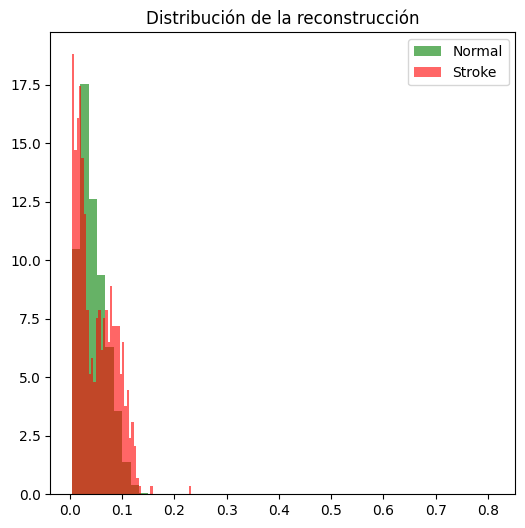

In [150]:
normal_ = mse[(y_test==0).values]
stroke_ = mse[(y_test==1).values]

fig, ax = plt.subplots(figsize=(6,6))

ax.hist(normal_, bins=50, density=True, label="Normal", alpha=.6, color="green")
ax.hist(stroke_, bins=50, density=True, label="Stroke", alpha=.6, color="red")

plt.title("Distribución de la reconstrucción")
plt.legend()
plt.show()

¿Podemos diferenciar la clase normal de los enfermos?, ¿qué opinas?

In [151]:
error_test = tf.keras.losses.MSE(X_new_test, reconstructions).numpy()
error_test

array([0.02686344, 0.03773436, 0.05873767, ..., 0.10534921, 0.00789659,
       0.06116964], dtype=float32)

/tmp/ipykernel_5182/2888007264.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error_test)


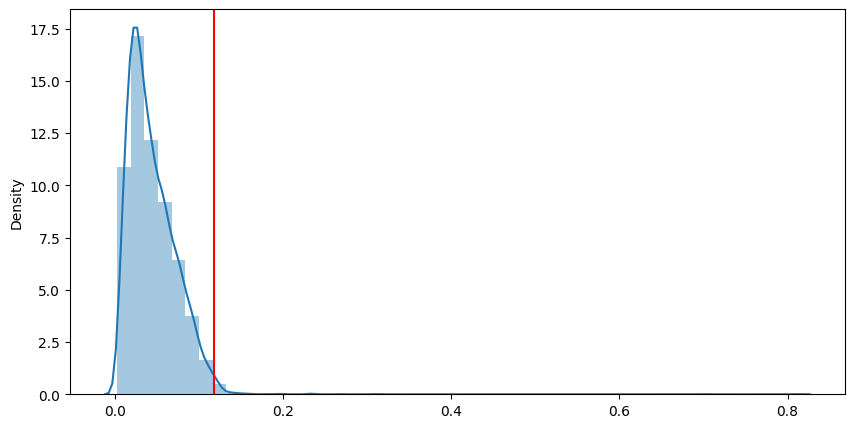

In [152]:
sns.distplot(error_test)
plt.axvline(q, 0, 1, color = 'red')
plt.show()

**Thresholds**

In [153]:
y_pred = (error_test > q).astype(int)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [155]:
print("----- Classification Report for outliers -----")
print(classification_report(y_test, y_pred))

----- Classification Report for outliers -----
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      8287
           1       0.22      0.03      0.05       643

    accuracy                           0.92      8930
   macro avg       0.57      0.51      0.50      8930
weighted avg       0.88      0.92      0.89      8930



0.1141827


/tmp/ipykernel_5182/444554992.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(error_test, norm_hist=True)


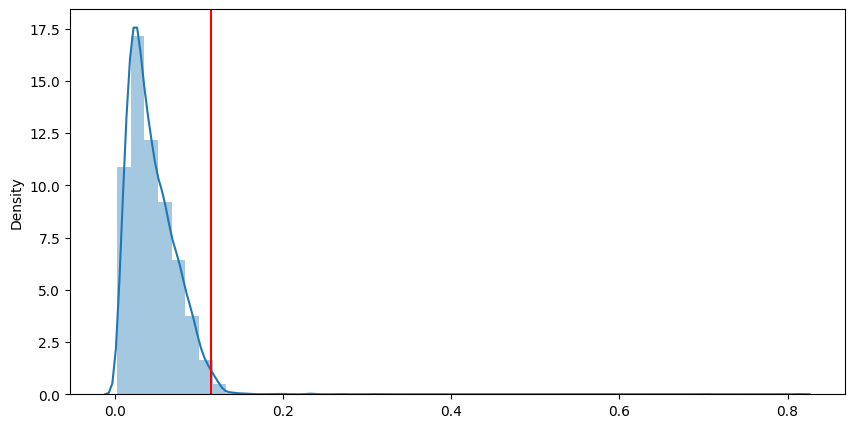

In [156]:
q = np.quantile(error, (0.99))
print(q)
sns.distplot(error_test, norm_hist=True)
plt.axvline(q, 0, 1, color = 'red')
plt.show()

In [157]:
q = np.quantile(error, (0.95))
print(q)
y_pred = (error_test > q).astype(int)
y_pred

0.09445999


array([0, 0, 0, ..., 1, 0, 0])

In [158]:
print("----- Classification Report for outliers -----")
print(classification_report(y_test, y_pred))

----- Classification Report for outliers -----
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      8287
           1       0.18      0.14      0.15       643

    accuracy                           0.89      8930
   macro avg       0.56      0.54      0.55      8930
weighted avg       0.88      0.89      0.89      8930



### **3. Preguntas**

1. ¿Con cual modelo se quedarían? Hay alguna forma de definir cuál es el mejor modelo para esta tarea de detección? Se quedarían con un modelo fácil de interpretar (isolation forest) o un modelo con relaciones mas complejas (autoencoder)?

2. ¿Las funciones de activación las modificarías?, ¿qué aportarían al entrenamiento del autoencoder?.
3. ¿Qué ocurriría si adicionas capas al autoencoder?
4. ¿De qué manera se puede mejorar el modelo?